# Spinodal and Binodal Line of a Two-components Polymer Blends

Polymer blends: (AB) + A, where (AB) can be any copolymers consisting of both A and B monomers. For example, AB diblock copolymer, AB3 star block copolymer, A(BA')3 star block copolymer, etc.

Critical point, spinodal and binodal lines are computed analytically for disorder-disorder macrophase separation of the polymer blends. SCFT calculations are required to computed other coexistence lines (between ordered microphase separation phases and disorder phase)

In [1]:
using PhaseDiagram
import Plots
using Plots: plot, plot!, savefig
using LaTeXStrings
using ArgCheck
using Roots
using Test

In [2]:
Plots.default(size=(600, 370))
fntf = :Helvetica
titlefont = Plots.font(fntf, pointsize=12)
guidefont = Plots.font(fntf, pointsize=12)
tickfont = Plots.font(fntf, pointsize=9)
legendfont = Plots.font(fntf, pointsize=8)
Plots.default(fontfamily=fntf)
Plots.default(titlefont=titlefont, guidefont=guidefont, tickfont=tickfont, legendfont=legendfont)
Plots.default(minorticks=true)
Plots.default(linewidth=1.5)
Plots.default(foreground_color_legend=nothing)
Plots.default(legend=false, grid=false)
Plots.default(framestyle=:box)
# Plots.default(widen=true)
# Plots.default(thickness_scaling=1.5)

# Keywords
# legend={:topleft, :topright, :top, :bottomleft, :bottomright, :bottom}
# lims, xlims, ylims = {:auto, :round, (-Inf, Inf)==:auto, (-1, 1)}

## A(BA')3 + A

A(BA'3): star block copolymer, one A arm, three BA' arm, BA' is a diblock.

### $\chi N \sim \phi$ phase diagram, for $f = 0.4, \alpha=0.14$

In [8]:
f = 0.4
α = 0.14
C = 1.0
ϕc, χNc = critical_point(f, α)

(0.7277142573518672, 18.733447195980045)

In [4]:
χNs(ϕ) = spinodal(ϕParameter(), ϕ, f, α)
ϕ = range(0.25, 0.95, step=0.001);
χNs_all = χNs.(ϕ);

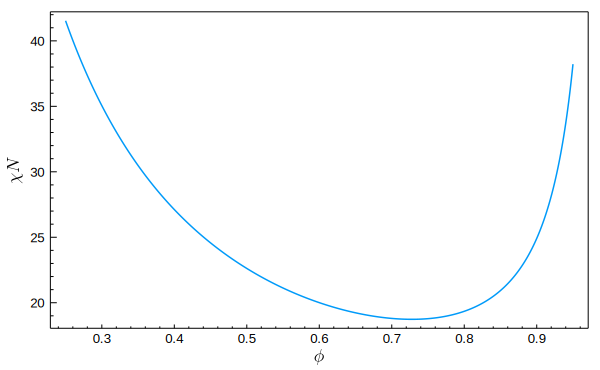

In [5]:
xlab = L"\phi"
ylab = L"\chi N"
lab = L"f=$f, α=$α"
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label=lab)

In [6]:
χN1 = range(χNc+0.1, 35, step=0.2);
χN2 = range(χNc+0.01, χNc+0.09, step=0.01)
χN = vcat(χN2, χN1);

In [9]:
binodal(20, f, α, C)

(0.5123142250283723, 0.8916662383473722)

In [10]:
C = 1.0
ϕb(χN) = binodal(χN, f, α, C)
ϕb_all = ϕb.(χN);

In [15]:
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕc, ϕb2);
χN_sort = vcat(reverse(χN), χNc, χN);
io = open("/Users/lyx/Downloads/boundary_DIS_DIS.txt", "w")
println(io, "# phih    xN")
for i in eachindex(ϕb_sort)
    phi, xN = ϕb_sort[i], χN_sort[i]
    println(io, "$phi \t $xN")
end
close(io)

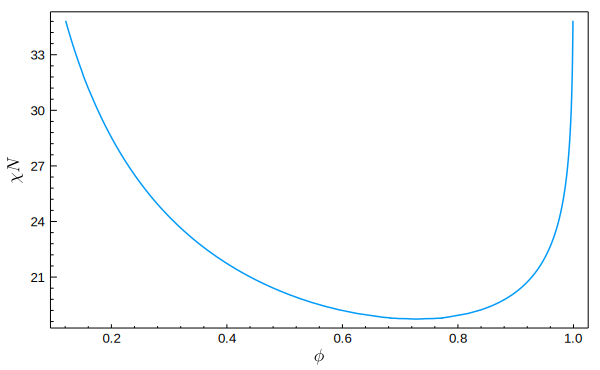

In [12]:
plot(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab)

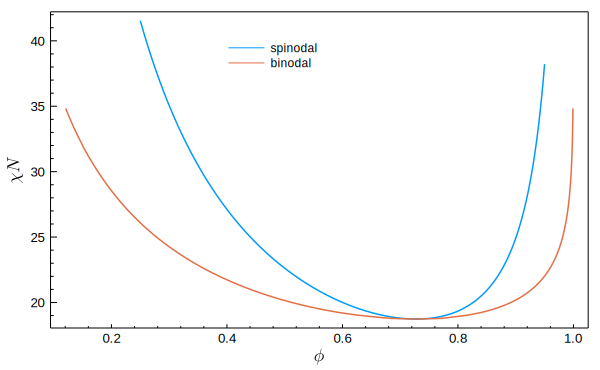

In [14]:
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label="spinodal", legend=:top)
plot!(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab, label="binodal")
# savefig("~/Downloads/chiN-phi-f0.4-alpha0.14.pdf")

### $\chi N \sim \phi$ phase diagram, for $f = 0.36, \alpha=0.14$

(ϕc, χNc) = (0.7277142573518672, 16.46494382459183)


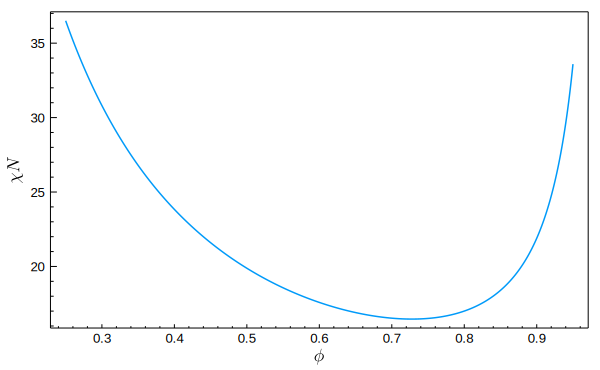

In [175]:
f = 0.36
α = 0.14
ϕc, χNc = critical_point(f, α)
@show ϕc, χNc
ϕ = range(0.25, 0.95, step=0.001);
χNs(ϕ) = spinodal(ϕParameter(), ϕ, f, α)
χNs_all = χNs.(ϕ);
xlab = L"\phi"
ylab = L"\chi N"
lab = L"f=$f, α=$α"
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label=lab)

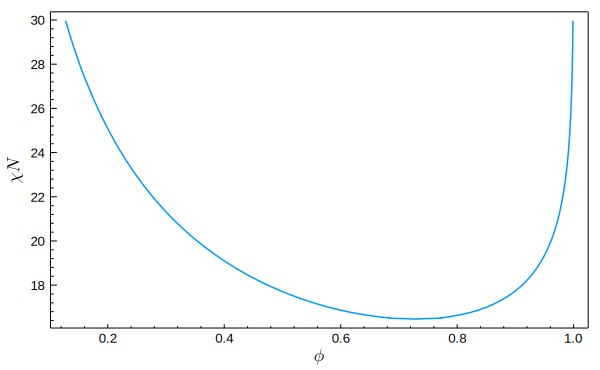

In [176]:
χN1 = range(χNc+0.1, 30, step=0.1);
χN2 = range(χNc+0.01, χNc+0.09, step=0.01)
χN = vcat(χN2, χN1)
ϕb(χN) = binodal(χN, f, α, C)
ϕb_all = ϕb.(χN);
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕc, ϕb2)
χN_sort = vcat(reverse(χN), χNc, χN)
io = open("/Users/lyx/Downloads/boundary_DIS_DIS.txt", "w")
println(io, "# phih    xN")
for i in eachindex(ϕb_sort)
    phi, xN = ϕb_sort[i], χN_sort[i]
    println(io, "$phi \t $xN")
end
close(io)
# plot(ϕb1, χN, xlabel=xlab, ylabel=ylab)
# plot!(ϕb2, χN, xlabel=xlab, ylabel=ylab)
plot(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab)

In [177]:
ϕb(22)

(0.2771775629001362, 0.9814198313881785)

In [74]:
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label="spinodal", legend=:top)
plot!(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab, label="binodal")
savefig("~/Downloads/chiN-phi-f0.36-alpha0.14.pdf")

### $\chi N \sim \phi$ phase diagram, for $f = 0.32, \alpha=0.14$

(ϕc, χNc) = (0.7277142573518672, 14.584863733894498)


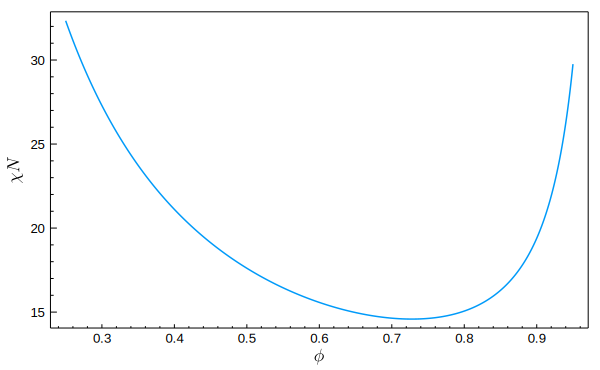

In [178]:
f = 0.32
α = 0.14
ϕc, χNc = critical_point(f, α)
@show ϕc, χNc
ϕ = range(0.25, 0.95, step=0.001);
χNs(ϕ) = spinodal(ϕParameter(), ϕ, f, α)
χNs_all = χNs.(ϕ);
xlab = L"\phi"
ylab = L"\chi N"
lab = L"f=$f, α=$α"
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label=lab)

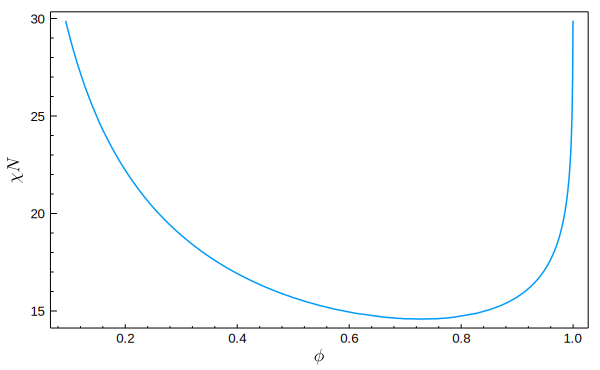

In [179]:
χN1 = range(χNc+0.1, 30, step=0.2);
χN2 = range(χNc+0.01, χNc+0.09, step=0.01)
χN = vcat(χN2, χN1)
# @show χN
ϕb(χN) = binodal(χN, f, α, C)
ϕb_all = ϕb.(χN);
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕc, ϕb2)
χN_sort = vcat(reverse(χN), χNc, χN)
io = open("/Users/lyx/Downloads/boundary_DIS_DIS.txt", "w")
println(io, "# phih    xN")
for i in eachindex(ϕb_sort)
    phi, xN = ϕb_sort[i], χN_sort[i]
    println(io, "$phi \t $xN")
end
close(io)
# plot(ϕb1, χN, xlabel=xlab, ylabel=ylab)
# plot!(ϕb2, χN, xlabel=xlab, ylabel=ylab)
plot(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab)

In [77]:
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label="spinodal", legend=:top)
plot!(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab, label="binodal")
savefig("~/Downloads/chiN-phi-f0.32-alpha0.14.pdf")

### $\chi N \sim \phi$ phase diagram, for $f = 0.28, \alpha=0.14$

(ϕc, χNc) = (0.7277142573518672, 13.009338330541697)


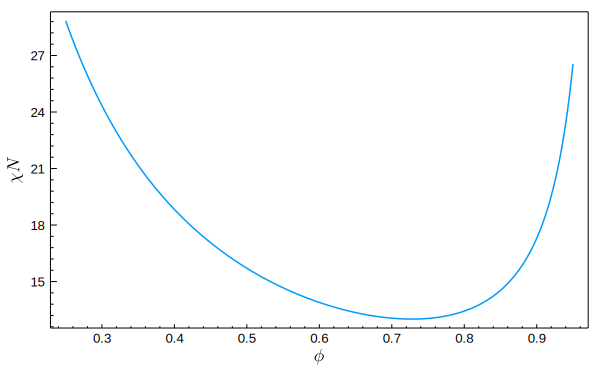

In [180]:
f = 0.28
α = 0.14
ϕc, χNc = critical_point(f, α)
@show ϕc, χNc
ϕ = range(0.25, 0.95, step=0.001);
χNs(ϕ) = spinodal(ϕParameter(), ϕ, f, α)
χNs_all = χNs.(ϕ);
xlab = L"\phi"
ylab = L"\chi N"
lab = L"f=$f, α=$α"
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label=lab)

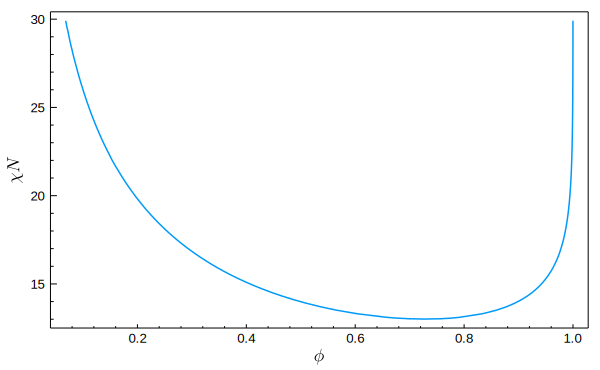

In [181]:
χN1 = range(χNc+0.1, 30, step=0.2);
χN2 = range(χNc+0.01, χNc+0.09, step=0.01)
χN = vcat(χN2, χN1)
# @show χN
ϕb(χN) = binodal(χN, f, α, C)
ϕb_all = ϕb.(χN);
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕc, ϕb2)
χN_sort = vcat(reverse(χN), χNc, χN)
io = open("/Users/lyx/Downloads/boundary_DIS_DIS.txt", "w")
println(io, "# phih    xN")
for i in eachindex(ϕb_sort)
    phi, xN = ϕb_sort[i], χN_sort[i]
    println(io, "$phi \t $xN")
end
close(io)
# plot(ϕb1, χN, xlabel=xlab, ylabel=ylab)
# plot!(ϕb2, χN, xlabel=xlab, ylabel=ylab)
plot(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab)

In [182]:
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label="spinodal", legend=:top)
plot!(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab, label="binodal")
savefig("~/Downloads/chiN-phi-f0.28-alpha0.14.pdf")

### $\chi N \sim \phi$ phase diagram, for $\alpha = 0.4, f=0.4$

(ϕc, χNc) = (0.6125741132772068, 9.25316341690053)


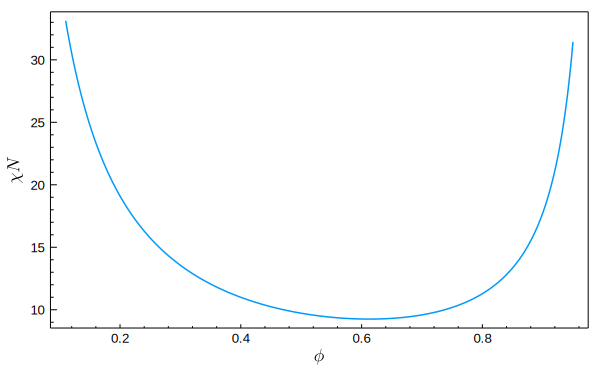

In [122]:
f = 0.4
α = 0.4
ϕc, χNc = critical_point(f, α)
@show ϕc, χNc
ϕ = range(0.11, 0.95, step=0.001);
χNs(ϕ) = spinodal(ϕParameter(), ϕ, f, α)
χNs_all = χNs.(ϕ);
xlab = L"\phi"
ylab = L"\chi N"
lab = L"f=$f, α=$α"
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label=lab)

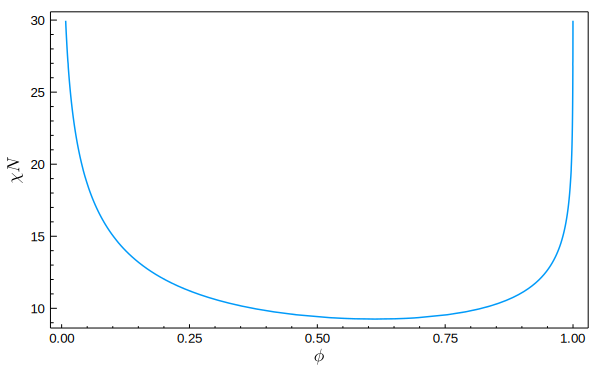

In [123]:
χN1 = range(χNc+0.1, 30, step=0.2);
χN2 = range(χNc+0.01, χNc+0.09, step=0.01)
χN = vcat(χN2, χN1)
# @show χN
ϕb(χN) = binodal(χN, f, α, C)
ϕb_all = ϕb.(χN);
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕc, ϕb2)
χN_sort = vcat(reverse(χN), χNc, χN)
# plot(ϕb1, χN, xlabel=xlab, ylabel=ylab)
# plot!(ϕb2, χN, xlabel=xlab, ylabel=ylab)
plot(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab)

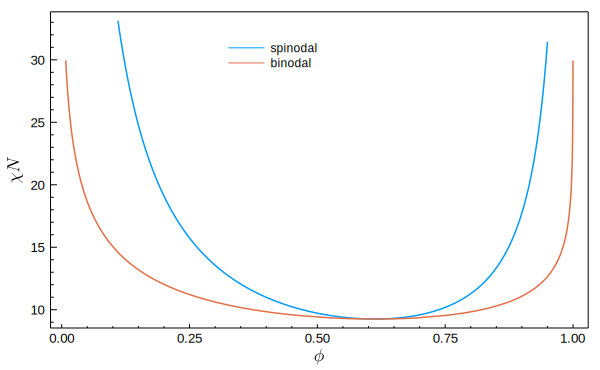

In [125]:
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label="spinodal", legend=:top)
plot!(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab, label="binodal")
# savefig("~/Downloads/chiN-phi-f0.4-alpha0.4.pdf")

### $\alpha \sim \phi$ phase diagram, for $f=0.4, \chi N = 32$

In [224]:
χN = 32.0
f = 0.4
α = range(0.01, 1.0, step=0.01)

0.01:0.01:1.0

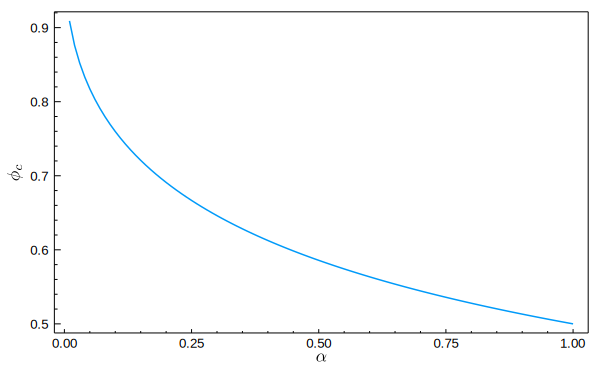

In [225]:
cpt = critical_point.(f, α)
ϕc = [x[1] for x in cpt];
χNc = [x[2] for x in cpt];
plot(α, ϕc, xlabel=L"\alpha", ylabel=L"\phi_c")

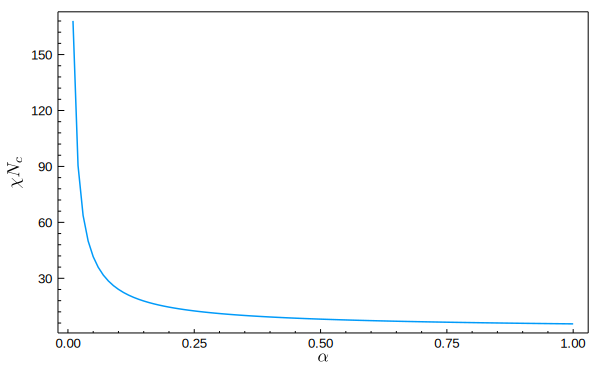

In [226]:
plot(α, χNc, xlabel=L"\alpha", ylabel=L"\chi N_c")

In [227]:
func(x) = critical_point(f, x)[2] - χN
αc = find_zero(func, (0.01, 0.1))
ϕcc = critical_point(f, αc)[1]
@show αc, ϕcc

(αc, ϕcc) = (0.06925207756232687, 0.7916666666666667)


(0.06925207756232687, 0.7916666666666667)

In [228]:
spinodal_α(α) = spinodal(χNParameter(), χN, f, α)

spinodal_α (generic function with 1 method)

In [234]:
α1 = range(0.09, 0.2, step=0.01);
α2 = range(0.07, 0.09, step=0.001)
α = vcat(α2, α1)
# α = range(0.07, 0.2, step=0.01)
ϕs_all = spinodal_α.(α)

33-element Array{Tuple{Float64,Float64},1}:
 (0.7508177880586044, 0.8258191167033002)
 (0.7267333510882186, 0.8411706003984795)
 (0.7081084623501566, 0.851305117896757)
 (0.6921363369577396, 0.8590194849600686)
 (0.6778495184976945, 0.8652717277485518)
 (0.6647741800618613, 0.8705267458640646)
 (0.6526350384755973, 0.8750513650331746)
 (0.6412545470242454, 0.8790151138704155)
 (0.6305097207936547, 0.8825333703744366)
 (0.6203108049604775, 0.8856886676133622)
 (0.6105896271442811, 0.8885423173001634)
 (0.6012927462417658, 0.891141238669071)
 (0.5923771828226599, 0.8935222074212426)
 ⋮
 (0.531490414983036, 0.9073598936589393)
 (0.47298010272404706, 0.917644897275953)
 (0.42690146382115823, 0.924266465471771)
 (0.38936515913778963, 0.9289218778992474)
 (0.3580785937516179, 0.9323861498381257)
 (0.3315472765914421, 0.9350697869006214)
 (0.3087366940825981, 0.937212379991476)
 (0.2889007583657053, 0.938963824967628)
 (0.27148471044776556, 0.9404229692907966)
 (0.2560660085280208, 0.94165775

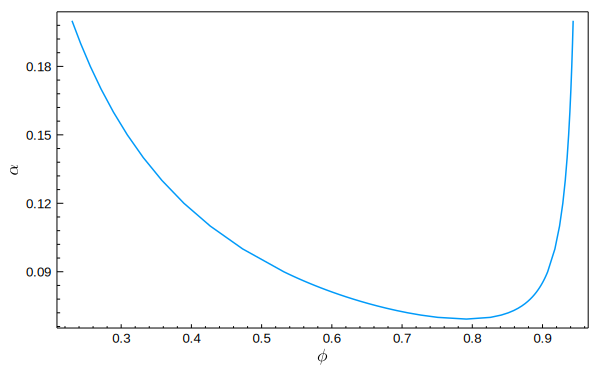

In [235]:
ϕs1 = [x[1] for x in ϕs_all];
ϕs2 = [x[2] for x in ϕs_all];
ϕs_sort = vcat(reverse(ϕs1), ϕcc, ϕs2)
α_sort = vcat(reverse(α), αc, α)
# plot(ϕs1, α, xlabel=L"\phi", ylabel=L"\alpha")
# plot!(ϕs2, α, xlabel=L"\phi", ylabel=L"\alpha")
plot(ϕs_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha")

In [236]:
binodal_α(α) = binodal(χN, f, α, 1.0)

binodal_α (generic function with 1 method)

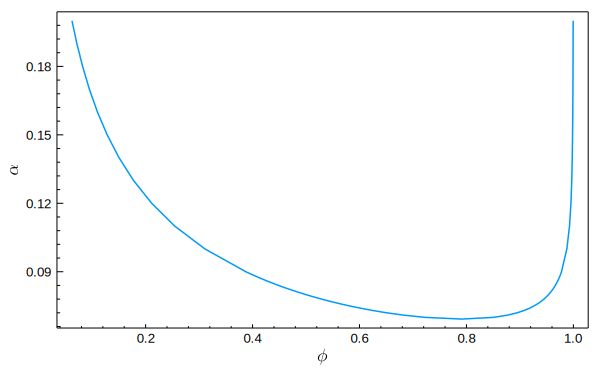

In [237]:
ϕb_all = binodal_α.(α)
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕcc, ϕb2)
α_sort = vcat(reverse(α), αc, α)
io = open("/Users/lyx/Downloads/boundary_DIS_DIS_f0.4_xN32.txt", "w")
println(io, "# phih    alpha")
for i in eachindex(ϕb_sort)
    phi, α = ϕb_sort[i], α_sort[i]
    println(io, "$phi \t $α")
end
close(io)
# plot(ϕb1, α, xlabel=L"\phi", ylabel=L"\alpha")
# plot!(ϕb2, α, xlabel=L"\phi", ylabel=L"\alpha")
plot(ϕb_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha")

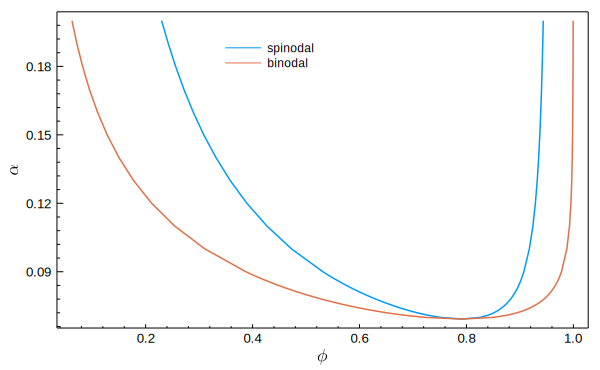

In [238]:
plot(ϕs_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha", label="spinodal", legend=:top)
plot!(ϕb_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha", label="binodal")
# savefig("~/Downloads/alpha-phi-f0.4-chiN32.pdf")

### $\alpha \sim \phi$ phase diagram, for $f=0.4, \chi N = 20$

In [88]:
χN = 20.0
f = 0.4
α = range(0.01, 1.0, step=0.01)

0.01:0.01:1.0

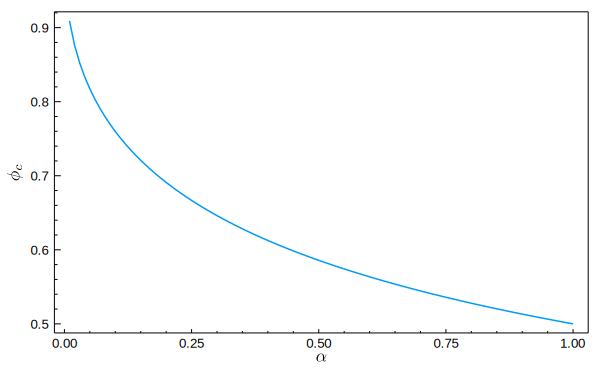

In [89]:
cpt = critical_point.(f, α)
ϕc = [x[1] for x in cpt];
χNc = [x[2] for x in cpt];
plot(α, ϕc, xlabel=L"\alpha", ylabel=L"\phi_c")

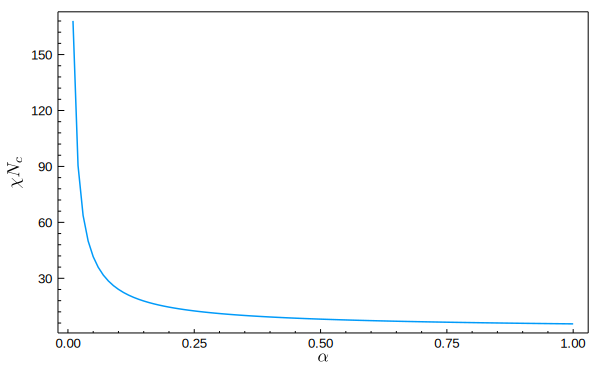

In [90]:
plot(α, χNc, xlabel=L"\alpha", ylabel=L"\chi N_c")

In [91]:
func(x) = critical_point(f, x)[2] - χN
αc = find_zero(func, (0.01, 1.0))
ϕcc = critical_point(f, αc)[1]
@show αc, ϕcc

(αc, ϕcc) = (0.12803222535310826, 0.736476861652635)


(0.12803222535310826, 0.736476861652635)

In [92]:
spinodal_α(α) = spinodal(χNParameter(), χN, f, α)

spinodal_α (generic function with 1 method)

In [93]:
α = range(0.13, 1.0, step=0.01)
ϕs_all = spinodal_α.(α)

88-element Array{Tuple{Float64,Float64},1}:
 (0.6856769157553414, 0.7790666739882484)
 (0.6003508058197942, 0.8262364957675075)
 (0.5467242553416775, 0.846794263176841)
 (0.5048257808604082, 0.8597575524729251)
 (0.4701056704354248, 0.8689466171462745)
 (0.4404701628320892, 0.8758878618592689)
 (0.4147002993826297, 0.8813523321963177)
 (0.3919945995190116, 0.8857831782587662)
 (0.37178605193632575, 0.8894573343070604)
 (0.3536536583019839, 0.8925584629101373)
 (0.33727397595305086, 0.8952139467522631)
 (0.32239211237062326, 0.8975152950367842)
 (0.30880319002587875, 0.8995301433074546)
 ⋮
 (0.08443146011020108, 0.9241515611132696)
 (0.08348626634082768, 0.9242297830418884)
 (0.08256201598262392, 0.9243061158855079)
 (0.0816580200382721, 0.924380627304723)
 (0.08077361942969863, 0.9244533817650445)
 (0.0799081833900604, 0.9245244407234148)
 (0.07906110795843369, 0.9245938628018002)
 (0.07823181456962452, 0.924661703948894)
 (0.07741974873215451, 0.9247280175908694)
 (0.07662437878805017

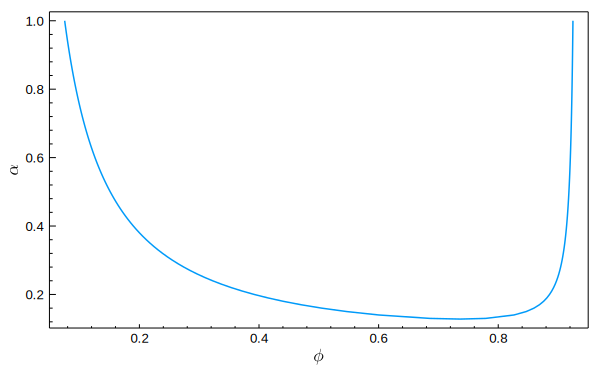

In [94]:
ϕs1 = [x[1] for x in ϕs_all];
ϕs2 = [x[2] for x in ϕs_all];
ϕs_sort = vcat(reverse(ϕs1), ϕcc, ϕs2)
α_sort = vcat(reverse(α), αc, α)
# plot(ϕs1, α, xlabel=L"\phi", ylabel=L"\alpha")
# plot!(ϕs2, α, xlabel=L"\phi", ylabel=L"\alpha")
plot(ϕs_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha")

In [95]:
binodal_α(α) = binodal(χN, f, α, 1.0)

binodal_α (generic function with 1 method)

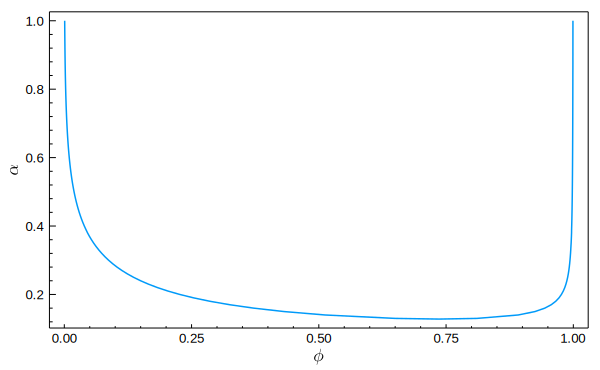

In [96]:
ϕb_all = binodal_α.(α)
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕcc, ϕb2)
α_sort = vcat(reverse(α), αc, α)
# plot(ϕb1, α, xlabel=L"\phi", ylabel=L"\alpha")
# plot!(ϕb2, α, xlabel=L"\phi", ylabel=L"\alpha")
plot(ϕb_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha")

In [97]:
plot(ϕs_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha", label="spinodal", legend=:top)
plot!(ϕb_sort, α_sort, xlabel=L"\phi", ylabel=L"\alpha", label="binodal")
savefig("~/Downloads/alpha-phi-f0.4-chiN20.pdf")

### $f \sim \phi$ phase diagram, for $\alpha = 0.14, \chi N = 32$

In [98]:
χN = 32.0
α = 0.14
f = range(0.1, 0.8, step=0.01)

0.1:0.01:0.8

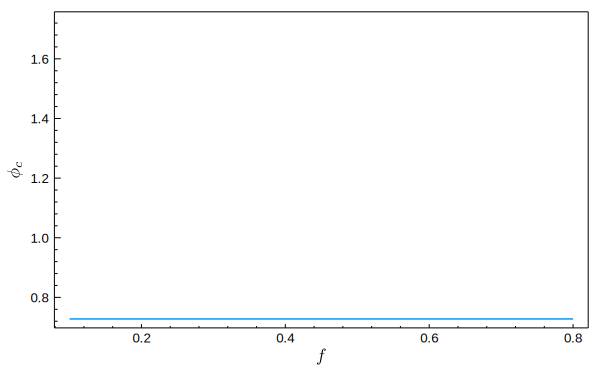

In [99]:
cpt = critical_point.(f, α)
ϕc = [x[1] for x in cpt];
χNc = [x[2] for x in cpt];
plot(f, ϕc, xlabel=L"f", ylabel=L"\phi_c")

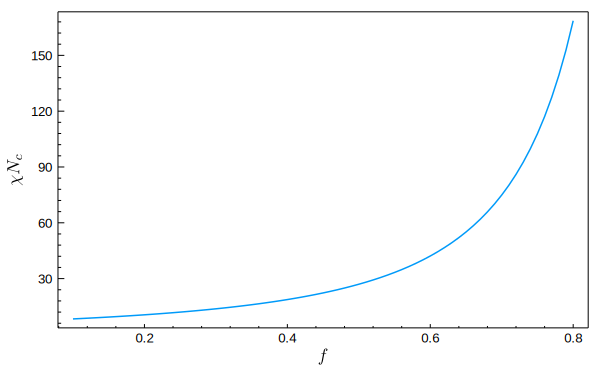

In [100]:
plot(f, χNc, xlabel=L"f", ylabel=L"\chi N_c")

In [101]:
func(x) = critical_point(x, α)[2] - χN
fc = find_zero(func, (0.1, 1.0))
ϕcc = ϕc[1] # ϕ at critical point is independent on f 
@show fc, ϕcc

(fc, ϕcc) = (0.5409234476094695, 0.7277142573518672)


(0.5409234476094695, 0.7277142573518672)

In [102]:
spinodal_f(f) = spinodal(χNParameter(), χN, f, α)

spinodal_f (generic function with 1 method)

In [103]:
f = range(0.16, 0.54, step=0.01)
ϕs_all = spinodal_f.(f)

39-element Array{Tuple{Float64,Float64},1}:
 (0.16246906193780397, 0.9735600520887591)
 (0.1665398308694993, 0.9727868389768396)
 (0.1707687327776215, 0.9719768693299675)
 (0.17516431915368103, 0.9711276224057502)
 (0.17973575378333662, 0.9702363444309491)
 (0.18449286949781107, 0.9693000208356977)
 (0.1894462316721625, 0.9683153443586443)
 (0.1946072094922191, 0.9672786782749303)
 (0.1999880562066822, 0.9661860138368477)
 (0.20560199982133648, 0.9650329208135842)
 (0.21146334599143513, 0.9638144897593736)
 (0.21758759524342225, 0.9625252643121095)
 (0.22399157713146073, 0.9611591614046946)
 ⋮
 (0.3719997059237393, 0.9234208630425359)
 (0.38739831848348966, 0.918667188076277)
 (0.40395584724901634, 0.9133404927745963)
 (0.42183587412450746, 0.9073209943842129)
 (0.4412466371328723, 0.9004484246583091)
 (0.4624626031654141, 0.8925009429039011)
 (0.4858625471830563, 0.8831576098993845)
 (0.5120031752611931, 0.8719253961673783)
 (0.5417806384790486, 0.8579783904969733)
 (0.576859382820656

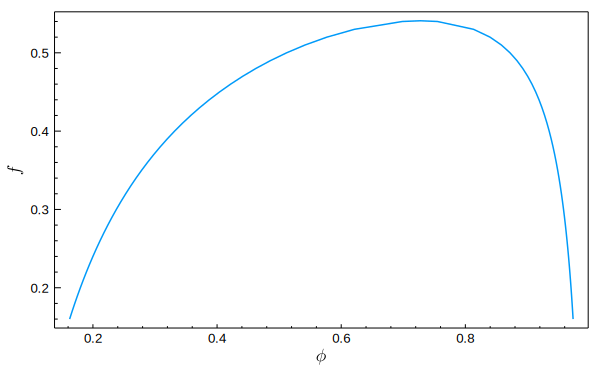

In [104]:
ϕs1 = [x[1] for x in ϕs_all];
ϕs2 = [x[2] for x in ϕs_all];
ϕs_sort = vcat(ϕs1, ϕcc, reverse(ϕs2))
f_sort = vcat(f, fc, reverse(f))
# plot(ϕs1, f, xlabel=L"\phi", ylabel=L"f")
# plot!(ϕs2, f, xlabel=L"\phi", ylabel=L"f")
plot(ϕs_sort, f_sort, xlabel=L"\phi", ylabel=L"f")

In [105]:
binodal_f(f) = binodal(χN, f, α, 1.0)

binodal_f (generic function with 1 method)

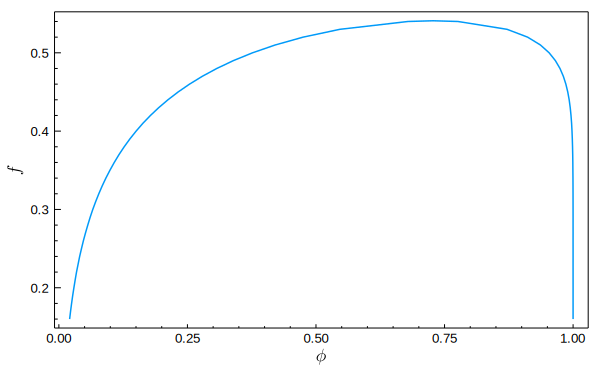

In [106]:
ϕb_all = binodal_f.(f)
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(ϕb1, ϕcc, reverse(ϕb2))
f_sort = vcat(f, fc, reverse(f))
# plot(ϕb1, f, xlabel=L"\phi", ylabel=L"f")
# plot!(ϕb2, f, xlabel=L"\phi", ylabel=L"f")
plot(ϕb_sort, f_sort, xlabel=L"\phi", ylabel=L"f")

In [107]:
plot(ϕs_sort, f_sort, xlabel=L"\phi", ylabel=L"f", label="spinodal", legend=:bottom)
plot!(ϕb_sort, f_sort, xlabel=L"\phi", ylabel=L"f", label="binodal")
savefig("~/Downloads/f-phi-alpha0.14-chiN32.pdf")

### $f \sim \phi$ phase diagram, for $\alpha = 0.14, \chi N = 20$

In [108]:
χN = 20.0
α = 0.14
f = range(0.1, 0.8, step=0.01)

0.1:0.01:0.8

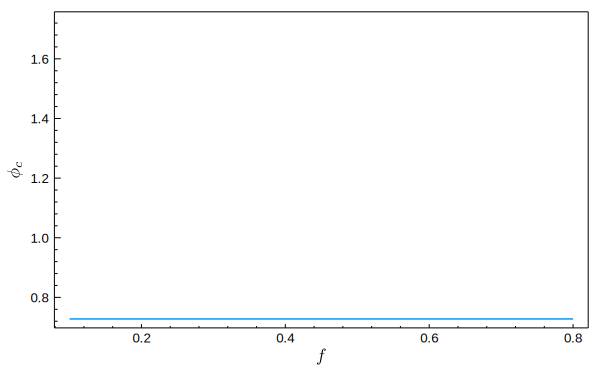

In [109]:
cpt = critical_point.(f, α)
ϕc = [x[1] for x in cpt];
χNc = [x[2] for x in cpt];
plot(f, ϕc, xlabel=L"f", ylabel=L"\phi_c")

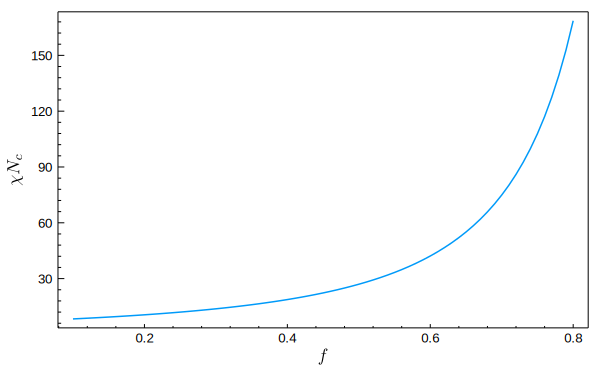

In [110]:
plot(f, χNc, xlabel=L"f", ylabel=L"\chi N_c")

In [111]:
func(x) = critical_point(x, α)[2] - χN
fc = find_zero(func, (0.1, 1.0))
ϕcc = ϕc[1] # ϕ at critical point is independent on f 
@show fc, ϕcc

(fc, ϕcc) = (0.4193089896273227, 0.7277142573518672)


(0.4193089896273227, 0.7277142573518672)

In [112]:
spinodal_f(f) = spinodal(χNParameter(), χN, f, α)

spinodal_f (generic function with 1 method)

In [113]:
f1 = range(0.16, 0.41, step=0.01)
f2 = range(0.411, 0.419, step=0.001)
f = vcat(f1, f2)
ϕs_all = spinodal_f.(f)

35-element Array{Tuple{Float64,Float64},1}:
 (0.26591167215781436, 0.9517349102846864)
 (0.2728279703382808, 0.9500947014158614)
 (0.28003468720302876, 0.9483582761691136)
 (0.2875500911902927, 0.9465170153047973)
 (0.29539415344428877, 0.9445612036985683)
 (0.30358878222365926, 0.9424798423099547)
 (0.31215810345052497, 0.9402604181987658)
 (0.3211287996710728, 0.9378886207563661)
 (0.3305305238794605, 0.9353479881901874)
 (0.3403964105970494, 0.9326194624188235)
 (0.35076371519293215, 0.9296808220083619)
 (0.3616746251156972, 0.9265059501731536)
 (0.37317730584707537, 0.9230638758107729)
 ⋮
 (0.5683739062284511, 0.8443415696420905)
 (0.6003508058197942, 0.8262364957675075)
 (0.6415018592568232, 0.7996685761681366)
 (0.64655693669709, 0.7961128024407211)
 (0.651895395201997, 0.7922813036602493)
 (0.6575761908744003, 0.7881151759387156)
 (0.6636827697475013, 0.7835310259036667)
 (0.6703402815973607, 0.7784037568902675)
 (0.6777524282343594, 0.7725297206544697)
 (0.6862951426437184, 0.7

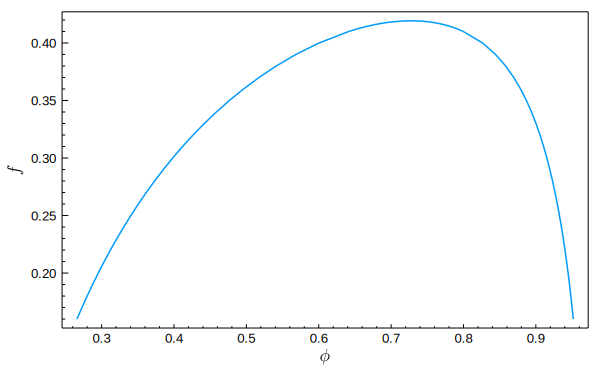

In [114]:
ϕs1 = [x[1] for x in ϕs_all];
ϕs2 = [x[2] for x in ϕs_all];
ϕs_sort = vcat(ϕs1, ϕcc, reverse(ϕs2))
f_sort = vcat(f, fc, reverse(f))
# plot(ϕs1, f, xlabel=L"\phi", ylabel=L"f")
# plot!(ϕs2, f, xlabel=L"\phi", ylabel=L"f")
plot(ϕs_sort, f_sort, xlabel=L"\phi", ylabel=L"f")

In [115]:
binodal_f(f) = binodal(χN, f, α, 1.0)

binodal_f (generic function with 1 method)

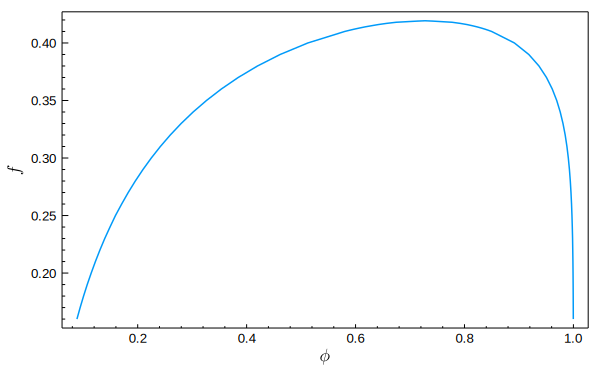

In [116]:
ϕb_all = binodal_f.(f)
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(ϕb1, ϕcc, reverse(ϕb2))
f_sort = vcat(f, fc, reverse(f))
# plot(ϕb1, f, xlabel=L"\phi", ylabel=L"f")
# plot!(ϕb2, f, xlabel=L"\phi", ylabel=L"f")
plot(ϕb_sort, f_sort, xlabel=L"\phi", ylabel=L"f")

In [117]:
plot(ϕs_sort, f_sort, xlabel=L"\phi", ylabel=L"f", label="spinodal", legend=:bottom)
plot!(ϕb_sort, f_sort, xlabel=L"\phi", ylabel=L"f", label="binodal")
savefig("~/Downloads/f-phi-alpha0.14-chiN20.pdf")